# Laboratorio de detección facial de visión artificial: Cuaderno del estudiante

En este laboratorio, usará Amazon Rekognition para realizar una detección facial de un rostro conocido.

Los pasos generales que realizará en este laboratorio son los siguientes:

1. Crear una colección.

2. Cargar una imagen de un rostro que desee detectar en el cuaderno de Amazon SageMaker.

3. Agregar la imagen a la colección.

4. Ver el cuadro de delimitación que se creó para la imagen.

5. Enumerar los rostros en la colección.

6. Utilizar la colección para encontrar un rostro.

7. Ver el cuadro delimitador del rostro que se encontró.

8. Eliminar la colección.

---

## Importación de paquetes de Python

Empiece por importar los paquetes Python que necesita.

En el siguiente código:

- *matplotlib* proporciona funciones de trazado
- *skimage* representa scikit-image, que proporciona varias herramientas útiles de manipulación de imágenes
- *boto3* representa el AWS SDK para Python (Boto3), que es la biblioteca de Python para AWS
- *numpy* representa NumPy, que es una biblioteca para manipular datos
- *PIL* representa la biblioteca de imágenes de Python, que contiene un conjunto de herramientas para dibujar imágenes


In [3]:
from skimage import io
from skimage.transform import rescale
from matplotlib import pyplot as plt

import boto3

import numpy as np

from PIL import Image, ImageDraw, ImageColor, ImageOps


## Tarea 1: crear una colección

En esta tarea, creará una colección en Amazon Rekognition.

Solo debe ejecutar este paso una vez.


In [4]:
client = boto3.client('rekognition')
collection_id = 'Collection'
response = client.create_collection(CollectionId=collection_id)
print('Collection ARN: ' + response['CollectionArn'])
print('Status Code:' + str(response['StatusCode']))
print('Done...')

Collection ARN: aws:rekognition:us-east-1:802085315584:collection/Collection
Status Code:200
Done...


## Tarea 2: cargar una imagen para buscar

Use la imagen de muestra provista, con el nombre *mum.jpg*, y cárguela en este cuaderno.

Luego, mire la imagen ejecutando la celda.


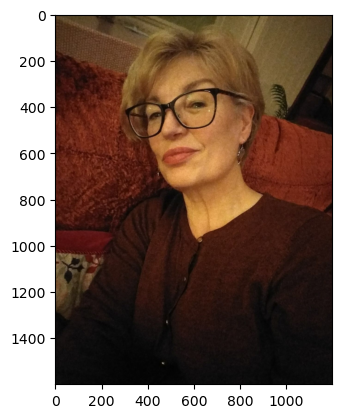

In [5]:
filename = "mum.jpg"

faceimage = io.imread(filename)

plt.imshow(faceimage)



Asegúrese de que el tamaño de la imagen sea menos de 4096 x 4096 píxeles. Si la imagen tiene un tamaño mayor, debe ajustarlo con el siguiente código:

`faceimage = rescale(faceimage, 0.50, mode='constant')`

**Nota:** El valor numérico representa el factor según el que se debe escalar. Un valor de *0.5* escalará la imagen a un 50 por ciento de la original.

Cuando se ajuste el tamaño de la imagen, guarde el archivo.

`io.imsave(filename, faceimage)`

**Sugerencia:** Debe copiar el código en una celda de código y ejecutarla.


## Tarea 3: agregar la imagen a la colección

Agregue la imagen a la colección que creó anteriormente.


In [6]:
externalimageid = filename

with open(filename, 'rb') as fimage:
    response = client.index_faces(CollectionId = collection_id,
                             Image={'Bytes': fimage.read()},
                             ExternalImageId=externalimageid,
                             MaxFaces=1,
                             QualityFilter="AUTO",
                             DetectionAttributes=['ALL'])

print('Results for ' + filename)
print('Faces indexed:')
for faceRecord in response['FaceRecords']:
     print('  Face ID: ' + faceRecord['Face']['FaceId'])
     print('  Location: {}'.format(faceRecord['Face']['BoundingBox']))

print('Faces not indexed:')
for unindexedFace in response['UnindexedFaces']:
    print(' Location: {}'.format(unindexedFace['FaceDetail']['BoundingBox']))
    print(' Reasons:')
    for reason in unindexedFace['Reasons']:
        print('   ' + reason)

Results for mum.jpg
Faces indexed:
  Face ID: 47931d03-c419-4394-8466-99180438f56a
  Location: {'Width': 0.3483645021915436, 'Height': 0.35312092304229736, 'Left': 0.30951350927352905, 'Top': 0.11020112037658691}
Faces not indexed:


## Tarea 4: ver el cuadro delimitador para el rostro detectado

Si se encuentra un rostro, los resultados deben incluir la ubicación del rostro que se detectó. Examine el cuadro delimitador en la imagen.

Para ello, use la biblioteca PIL, que importó anteriormente en este laboratorio. Al extraer BoundingBox, puede dibujar un conjunto de líneas alrededor de la imagen.


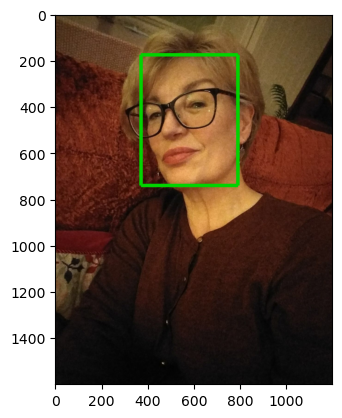

In [7]:

img = Image.open(filename)
imgWidth, imgHeight = img.size

draw = ImageDraw.Draw(img)
for faceRecord in response['FaceRecords']:
    box = faceRecord['Face']['BoundingBox']
    left = imgWidth * box['Left']
    top = imgHeight * box['Top']
    width = imgWidth * box['Width']
    height = imgHeight * box['Height']

    points = ((left,top),(left+width,top),(left+width,top+height),(left,top+height),(left,top))

    draw.line(points,fill='#00d400', width=15)
    
plt.imshow(img)

## Tarea 5: enumerar los rostros en la colección

Examine la imagen que tiene en la colección. 



In [8]:
maxResults=2
faces_count=0
tokens=True

response=client.list_faces(CollectionId=collection_id,
                           MaxResults=maxResults)

print('Faces in collection ' + collection_id)

while tokens:

    faces=response['Faces']

    for face in faces:
        print (face)
        faces_count+=1
    if 'NextToken' in response:
        nextToken=response['NextToken']
        response=client.list_faces(CollectionId=collection_id,
                                   NextToken=nextToken,MaxResults=maxResults)
    else:
        tokens=False

Faces in collection Collection
{'FaceId': '47931d03-c419-4394-8466-99180438f56a', 'BoundingBox': {'Width': 0.34836500883102417, 'Height': 0.3531210124492645, 'Left': 0.30951398611068726, 'Top': 0.11020100116729736}, 'ImageId': '59d87d59-b733-306a-94e8-0670b0a8dcdd', 'ExternalImageId': 'mum.jpg', 'Confidence': 99.99430084228516, 'IndexFacesModelVersion': '7.0'}


## Tarea 6: encontrar un rostro usando la colección

En este paso, usará la colección para detectar un rostro en una imagen.

Use la imagen de muestra provista, con el nombre *target.jpg*, y cárguela en este cuaderno.



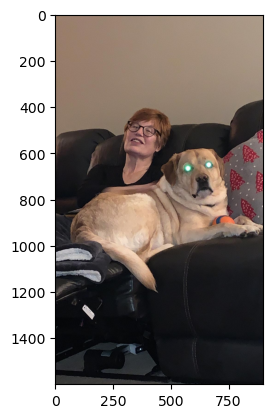

In [9]:
targetfilename = "target.jpg"

targetimage = Image.open(targetfilename)
plt.imshow(targetimage)

A continuación, llame la operación `search_faces_by_image` y vea si obtiene una coincidencia.

In [10]:
threshold = 70
maxFaces=2

with open(targetfilename, 'rb') as timage:        
    response2=client.search_faces_by_image(CollectionId=collection_id,
                            Image={'Bytes': timage.read()},
                            FaceMatchThreshold=threshold,
                            MaxFaces=maxFaces)

faceMatches=response2['FaceMatches']
print ('Matching faces')
for match in faceMatches:
        print ('FaceId:' + match['Face']['FaceId'])
        print ('Similarity: ' + "{:.2f}".format(match['Similarity']) + "%")
        print ('ExternalImageId: ' + match['Face']['ExternalImageId'])
        print

Matching faces
FaceId:47931d03-c419-4394-8466-99180438f56a
Similarity: 99.91%
ExternalImageId: mum.jpg


## Tarea 7: dibujar un cuadro delimitador alrededor del rostro descubierto

Dibuje un cuadro delimitador alrededor del rostro descubierto.

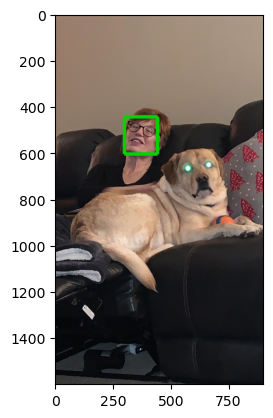

In [11]:
imgWidth, imgHeight = targetimage.size

draw = ImageDraw.Draw(targetimage)

box = response2['SearchedFaceBoundingBox']
left = imgWidth * box['Left']
top = imgHeight * box['Top']
width = imgWidth * box['Width']
height = imgHeight * box['Height']

points = ((left,top),(left+width,top),(left+width,top+height),(left,top+height),(left,top))
draw.line(points,fill='#00d400', width=15)
    
plt.imshow(targetimage)

## Tarea 8: eliminar la colección

Cuando finalice, elimine la colección. Para ello, ejecute el siguiente código: 


In [12]:
print('Attempting to delete collection ' + collection_id)
status_code=0
try:
    response=client.delete_collection(CollectionId=collection_id)
    status_code=response['StatusCode']
    print('All done!')
    print(status_code)
    
except ClientError as e:
    if e.response['Error']['Code'] == 'ResourceNotFoundException':
        print ('The collection ' + collection_id + ' was not found ')
    else:
        print ('Error other than Not Found occurred: ' + e.response['Error']['Message'])
    status_code=e.response['ResponseMetadata']['HTTPStatusCode']



Attempting to delete collection Collection
All done!
200


# ¡Felicitaciones!

Completó este laboratorio y ahora puede finalizarlo siguiendo las instrucciones en la guía del laboratorio.